In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import arff
import itertools
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_tweedie_deviance
from sklearn.datasets import fetch_openml

In [4]:
# 1. Load the ARFF file using the 'arff' package 
# Two ways of loading data is shared. In this .arff file is converted to data frame
# Data on frequency
file_path = "C:/Users/Roshmi/OneDrive/Desktop/freMTPL2freq.arff"

with open(file_path, 'r') as f:
    # Use liac-arff parser
    dataset = arff.load(f)

# 2. Extract column names (attributes) and row data
column_names = [attr[0] for attr in dataset['attributes']]
row_data = dataset['data']


In [5]:
# Build and export DataFrame
df = pd.DataFrame(row_data, columns=column_names)


In [6]:
df_freq=df

In [7]:
df_freq["IDPol"]=df_freq["IDpol"].astype(int)
df_freq.set_index("IDpol", inplace=True)

In [8]:
# Fetching data from scikit learn. This is the second way of loading data
# Data on severity

df_sev = fetch_openml(data_id=41215, as_frame=True).data

In [9]:
df_sev=df_sev.groupby('IDpol').sum()

In [10]:
df = df_freq.join(df_sev, how="left")

In [11]:
df["ClaimAmount"]= df["ClaimAmount"].fillna(0)

In [12]:
 for column_name in df.columns[[t is object for t in df.dtypes.values]]:
        df[column_name] = df[column_name].str.strip("'")

In [13]:
df["ClaimNb"] = df["ClaimNb"].clip(upper=4)
df["Exposure"] = df["Exposure"].clip(upper=1)
df["ClaimAmount"] = df["ClaimAmount"].clip(upper=200000)

In [15]:
df.loc[(df["ClaimAmount"] == 0) & (df["ClaimNb"] >= 1), "ClaimNb"] = 0


In [16]:
df["Density_log"] = np.log(df["Density"])
df_encoded = pd.get_dummies(
    df, columns=["Area", "VehPower", "VehBrand", "VehGas", "Region"]
)

In [17]:
# Creates 10 equal-sized buckets for Driver Age automatically
df_encoded["DrivAge_binned"] = pd.qcut(df_encoded["DrivAge"], q=10)

# Convert these new buckets into 1s and 0s as well
df_final = pd.get_dummies(df_encoded, columns=["DrivAge_binned", "VehAge"])

In [18]:
#  Clean up VehAge so it also has exactly 10 equal bins
df_encoded["VehAge_binned"] = pd.qcut(
    df_encoded["VehAge"], q=10, duplicates="drop"
)

#  Re-create the final encoded version with matching bins
df_final = pd.get_dummies(
    df_encoded, columns=["DrivAge_binned", "VehAge_binned"]
)

#  Scale the log density to match StandardScaler()
df_final["Density_log"] = (
    df_final["Density_log"] - df_final["Density_log"].mean()
) / df_final["Density_log"].std()



In [19]:
df["PurePremium"] = df["ClaimAmount"] / df["Exposure"]

# This can be indirectly approximated by a 2-step modeling: the product of the
# Frequency times the average claim amount per claim:
df["Frequency"] = df["ClaimNb"] / df["Exposure"]
df["AvgClaimAmount"] = df["ClaimAmount"] / np.fmax(df["ClaimNb"], 1)

with pd.option_context("display.max_columns", 15):
    print(df[df.ClaimAmount > 0].head())

       ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  ...  \
IDpol                                                                 ...   
139.0      1.0      0.75    F       7.0     1.0     61.0        50.0  ...   
190.0      1.0      0.14    B      12.0     5.0     50.0        60.0  ...   
414.0      1.0      0.14    E       4.0     0.0     36.0        85.0  ...   
424.0      2.0      0.62    F      10.0     0.0     51.0       100.0  ...   
463.0      1.0      0.31    A       5.0     0.0     45.0        50.0  ...   

      Region IDPol  ClaimAmount Density_log   PurePremium  Frequency  \
IDpol                                                                  
139.0    R11   139       303.00   10.203592    404.000000   1.333333   
190.0    R25   190      1981.84    4.025352  14156.000000   7.142857   
414.0    R11   414      1456.55    8.474703  10403.928571   7.142857   
424.0    R11   424     10834.00   10.203592  17474.193548   3.225806   
463.0    R73   463      3986

In [20]:
# To see how the df looks an .xlsx file is created
df.to_excel("C:/Users/Roshmi/OneDrive/Desktop/df_binned.xlsx")

In [21]:
# XGBoost requires all feature columns to be numeric. 
# We use pd.get_dummies to convert columns like 'Area' and 'VehBrand' into simple 0 and 1 columns.

cat_cols = ["Area", "VehBrand", "VehGas", "Region"]
num_cols = ["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density_log"]

df_numeric = pd.get_dummies(df[cat_cols], drop_first=True)
df_features = pd.concat([df[num_cols], df_numeric], axis=1)

In [22]:
# --- STEP 2: SPLIT DATA INTO TRAIN AND TEST SETS ---
# We split the entire dataframe so our features, targets, and exposures stay lined up.
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [23]:
# Extract the matching feature matrices for training and testing
X_train = df_features.loc[df_train.index]
X_test = df_features.loc[df_test.index]

In [24]:
# --- STEP 3: TRAIN THE FREQUENCY MODEL (POISSON) ---
# Target: 'Frequency' column (ClaimNb / Exposure)
# Weight: 'Exposure' column
#Adding global_baseline_freq as the Expected was appearing on lower side continuously
# Enhancing n_estimators to 200
#Introducing learning rate
# Introducing max depth so that tree captures more complex interactions

global_baseline_freq = df_train["ClaimNb"].sum() / df_train["Exposure"].sum()
model_freq = xgb.XGBRegressor(
    objective="count:poisson", 
    n_estimators=200,
    learning_rate= 0.05, 
    max_depth=6, 
    base_score=global_baseline_freq, 
    random_state=42)
model_freq.fit(X_train, df_train["Frequency"], sample_weight=df_train["Exposure"])

XGBRegressor(base_score=np.float64(0.07325538219707055), booster=None,
             callbacks=None, colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [25]:
# --- STEP 4: TRAIN THE SEVERITY MODEL (GAMMA) ---
# Filter: We only train severity on rows where a claim actually happened (ClaimAmount > 0)
# Target: 'AvgClaimAmount' column (ClaimAmount / ClaimNb)
# Weight: 'ClaimNb' column
train_mask = df_train["ClaimAmount"] > 0
X_train_sev = X_train[train_mask]

In [26]:
# Calculate the true average claim size from your training data
positive_claims = df_train[df_train["ClaimAmount"] > 0]
global_avg_severity = positive_claims["ClaimAmount"].sum() / positive_claims["ClaimNb"].sum()

# Re-initialize the severity model with this specific starting intercept
model_sev = xgb.XGBRegressor(
    objective="reg:gamma",
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    base_score=global_avg_severity,  # Forces the starting baseline to match reality
    random_state=42
)

In [27]:
#model_sev = xgb.XGBRegressor(objective="reg:gamma", n_estimators=100, random_state=42)
model_sev.fit(X_train_sev, df_train.loc[train_mask, "AvgClaimAmount"], sample_weight=df_train.loc[train_mask, "ClaimNb"])


XGBRegressor(base_score=np.float64(1959.2005964678438), booster=None,
             callbacks=None, colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_jobs=None, num_parallel_tree=None, ...)

In [28]:
# --- STEP 5: COMBINE PREDICTIONS FOR BURNING COST ---
# Predict frequency and severity on the test set, then multiply them together
pred_freq = model_freq.predict(X_test)
pred_sev = model_sev.predict(X_test)

In [29]:
predicted_burning_cost = pred_freq * pred_sev

In [30]:
# --- STEP 6: EVALUATE PERFORMANCE ---
# Compare your predicted burning cost against the true 'PurePremium' column in your test set
deviance_score = mean_tweedie_deviance(
    df_test["PurePremium"], 
    predicted_burning_cost, 
    power=1.6, 
    sample_weight=df_test["Exposure"]
)

print(f"XGBoost Frequency × Severity Burning Cost Deviance: {deviance_score:.4f}")

XGBoost Frequency × Severity Burning Cost Deviance: 52.1537


In [49]:

def plot_frequency_vs_exposure(df_test, pred_freq, feature_name, num_bins=10):
    """
    Plots Exposure as bars (left axis) and Actual vs Expected Frequency as lines (right axis)
    grouped by a specific feature.
    """
    # 1. Create a temporary DataFrame copy to safely add predictions
    plot_df = df_test.copy()
    plot_df["Expected_Freq"] = pred_freq
    
    # Calculate actual frequency for individual rows safely
    plot_df["Actual_Freq"] = plot_df["ClaimNb"] / plot_df["Exposure"]

     # 2. Group the feature into bins safely based on type
    # Check if the column contains string objects or text
    if plot_df[feature_name].dtype == 'object' or isinstance(plot_df[feature_name].iloc[0], str):
        # Text categories don't need percentile cuts; use them as they are
        plot_df["Bin"] = plot_df[feature_name].astype(str)
    else:
        # Numeric columns get split into percentiles (bins)
        try:
            plot_df["Bin"] = pd.qcut(plot_df[feature_name], q=num_bins, duplicates="drop").astype(str)
        except (ValueError, TypeError):
            plot_df["Bin"] = plot_df[feature_name].astype(str)


    # 3. Aggregate Exposure, Claims, and Expected Claims per bin
    # We must calculate exposure-weighted frequencies to match portfolio averages
    grouped = plot_df.groupby("Bin").agg(
        Total_Exposure=("Exposure", "sum"),
        Total_Claims=("ClaimNb", "sum"),
        Weighted_Expected_Freq=("Expected_Freq", lambda x: np.average(x, weights=plot_df.loc[x.index, "Exposure"]))
    ).reset_index()

    # Calculate actual portfolio frequency per bin
    grouped["Weighted_Actual_Freq"] = grouped["Total_Claims"] / grouped["Total_Exposure"]

    # Sort bins naturally for clean visualization
    grouped = grouped.sort_values("Bin")

    # 4. Initialize the Double-Y Axis Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # --- Left Axis: Exposure Bars ---
    ax1.bar(grouped["Bin"], grouped["Total_Exposure"], color="skyblue", alpha=0.5, label="Total Exposure")
    ax1.set_xlabel(f"Bins of {feature_name}", fontsize=11, fontweight="bold")
    ax1.set_ylabel("Total Exposure (Years / Policies)", color="darkblue", fontsize=11)
    ax1.tick_params(axis="y", labelcolor="darkblue")
    ax1.set_xticklabels(grouped["Bin"], rotation=45, ha="right")

    # --- Right Axis: Frequency Lines ---
    ax2 = ax1.twinx()
    ax2.plot(grouped["Bin"], grouped["Weighted_Actual_Freq"], color="red", marker="o", linewidth=2, label="Actual Frequency")
    ax2.plot(grouped["Bin"], grouped["Weighted_Expected_Freq"], color="darkgreen", marker="s", linewidth=2, linestyle="--", label="Expected Frequency (XGBoost)")
    ax2.set_ylabel("Claim Frequency (Claims / Exposure)", color="black", fontsize=11)
    ax2.tick_params(axis="y", labelcolor="black")

    # --- Formatting and Legends ---
    plt.title(f"Actual vs. Expected Claim Frequency & Exposure by {feature_name}", fontsize=14, fontweight="bold", pad=15)
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.tight_layout()
    plt.grid(True, alpha=0.15)
    plt.show()




C:\Users\Roshmi\AppData\Local\Temp\ipykernel_7600\1582268115.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(grouped["Bin"], rotation=45, ha="right")


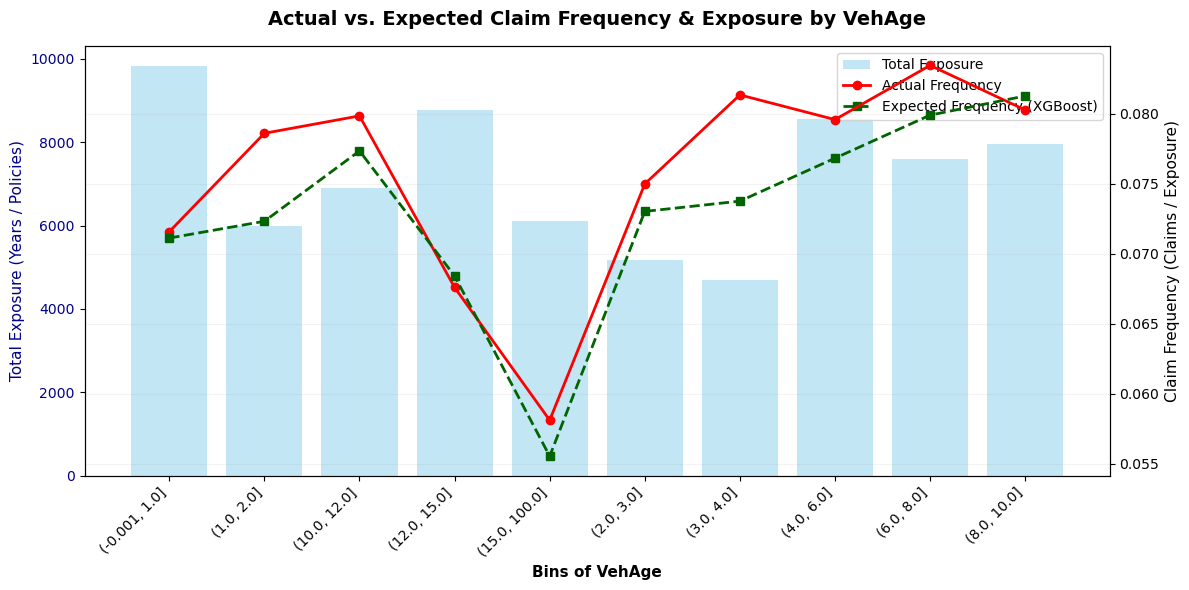

In [32]:
plot_frequency_vs_exposure(df_test, pred_freq, feature_name="VehAge",num_bins=10)

C:\Users\Roshmi\AppData\Local\Temp\ipykernel_7600\1582268115.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(grouped["Bin"], rotation=45, ha="right")


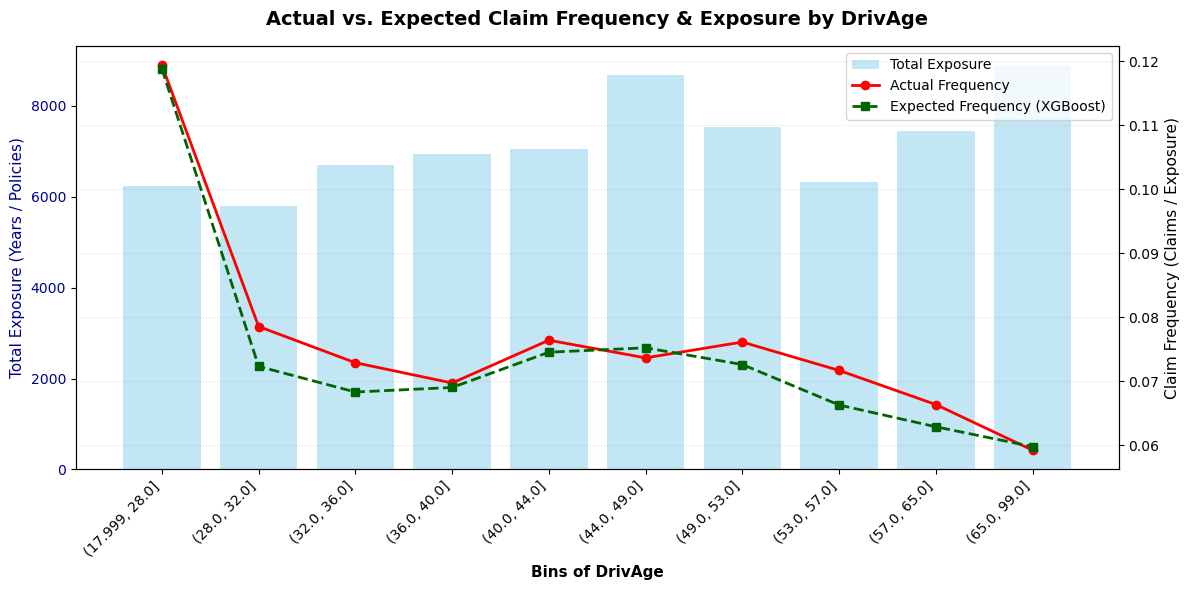

In [33]:
plot_frequency_vs_exposure(df_test, pred_freq, feature_name="DrivAge",num_bins=10)

C:\Users\Roshmi\AppData\Local\Temp\ipykernel_7600\1582268115.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(grouped["Bin"], rotation=45, ha="right")


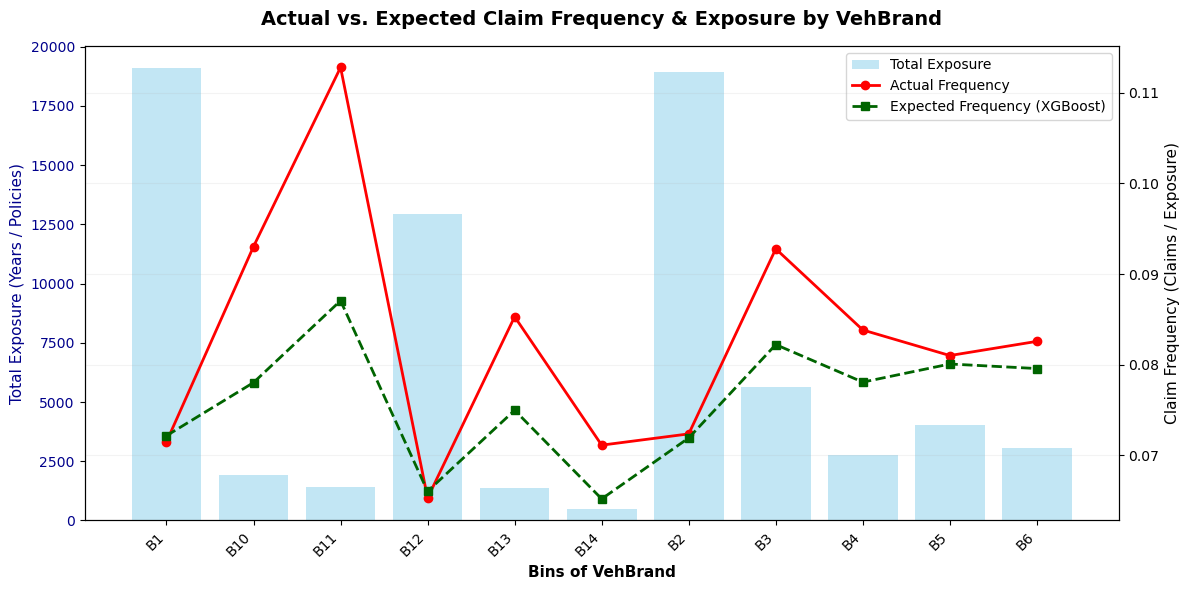

In [34]:
plot_frequency_vs_exposure(df_test, pred_freq, feature_name="VehBrand",num_bins=10)

C:\Users\Roshmi\AppData\Local\Temp\ipykernel_7600\1582268115.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(grouped["Bin"], rotation=45, ha="right")


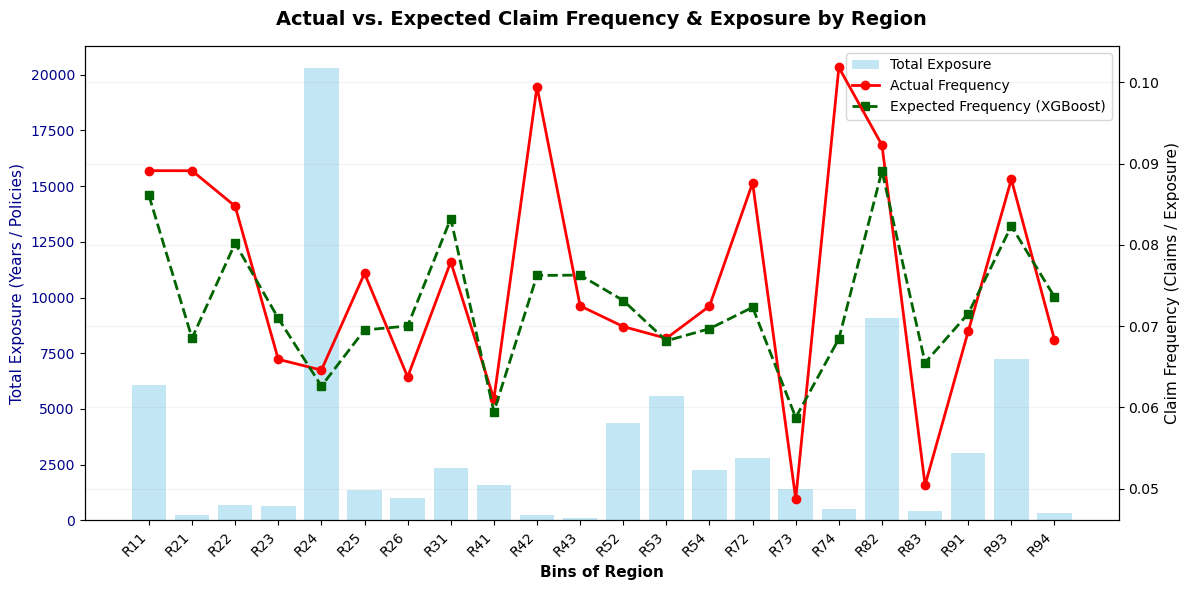

In [35]:
plot_frequency_vs_exposure(df_test, pred_freq, feature_name="Region",num_bins=10)

C:\Users\Roshmi\AppData\Local\Temp\ipykernel_7600\1582268115.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(grouped["Bin"], rotation=45, ha="right")


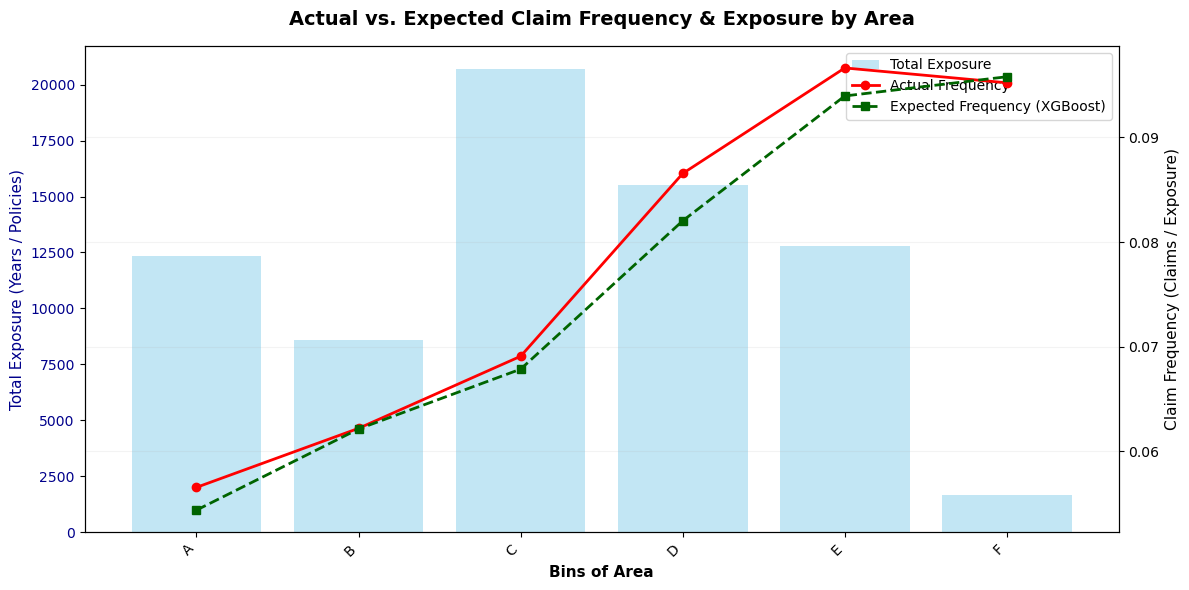

In [36]:
plot_frequency_vs_exposure(df_test, pred_freq, feature_name="Area",num_bins=10)

In [37]:
def plot_burning_cost_vs_exposure(df_test, pred_freq, pred_sev, feature_name, num_bins=10):
    """
    Plots Exposure as bars (left axis) and Actual vs Expected Burning Cost (Pure Premium) 
    as lines (right axis) grouped by a specific feature.
    """
    # 1. Create a copy and calculate individual row metrics
    plot_df = df_test.copy()
    
    # Calculate predicted burning cost (Frequency * Severity)
    plot_df["Expected_Burning_Cost"] = pred_freq * pred_sev

    # 2. Group the feature into bins safely based on data type
    if plot_df[feature_name].dtype == 'object' or isinstance(plot_df[feature_name].iloc[0], str):
        plot_df["Bin"] = plot_df[feature_name].astype(str)
        
        # Aggregate for categorical text columns
        grouped = plot_df.groupby("Bin").agg(
            Total_Exposure=("Exposure", "sum"),
            Total_Claim_Amount=("ClaimAmount", "sum"),
            Weighted_Expected_BC=("Expected_Burning_Cost", lambda x: np.average(x, weights=plot_df.loc[x.index, "Exposure"]))
        ).reset_index()
        grouped = grouped.sort_values("Bin")
    else:
        # Quantile binning for numeric columns with duplicate dropping
        plot_df["Bin_Interval"] = pd.qcut(plot_df[feature_name], q=num_bins, duplicates="drop")
        
        # Aggregate using Exposure-weighted averages for the portfolio metrics
        grouped = plot_df.groupby("Bin_Interval").agg(
            Total_Exposure=("Exposure", "sum"),
            Total_Claim_Amount=("ClaimAmount", "sum"),
            Weighted_Expected_BC=("Expected_Burning_Cost", lambda x: np.average(x, weights=plot_df.loc[x.index, "Exposure"]))
        ).reset_index()
        
        # Sort numerically by the interval endpoints and convert to string labels
        grouped = grouped.sort_values(by="Bin_Interval")
        grouped["Bin"] = grouped["Bin_Interval"].astype(str)

    # 3. Calculate actual portfolio Pure Premium per bin
    grouped["Actual_Pure_Premium"] = grouped["Total_Claim_Amount"] / grouped["Total_Exposure"]

    # 4. Initialize the Double-Y Axis Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # --- Left Axis: Exposure Bars ---
    ax1.bar(grouped["Bin"], grouped["Total_Exposure"], color="skyblue", alpha=0.5, label="Total Exposure")
    ax1.set_xlabel(f"Bins of {feature_name}", fontsize=11, fontweight="bold")
    ax1.set_ylabel("Total Exposure (Years / Policies)", color="darkblue", fontsize=11)
    ax1.tick_params(axis="y", labelcolor="darkblue")
    ax1.set_xticklabels(grouped["Bin"], rotation=45, ha="right")

    # --- Right Axis: Burning Cost Lines ---
    ax2 = ax1.twinx()
    ax2.plot(grouped["Bin"], grouped["Actual_Pure_Premium"], color="darkred", marker="o", linewidth=2, label="Actual Pure Premium")
    ax2.plot(grouped["Bin"], grouped["Weighted_Expected_BC"], color="forestgreen", marker="s", linewidth=2, linestyle="--", label="Expected Burning Cost (XGBoost F×S)")
    ax2.set_ylabel("Burning Cost / Pure Premium (€ or Currency)", color="black", fontsize=11)
    ax2.tick_params(axis="y", labelcolor="black")

    # --- Formatting and Legends ---
    plt.title(f"Actual vs. Expected Burning Cost & Exposure by {feature_name}", fontsize=14, fontweight="bold", pad=15)
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.tight_layout()
    plt.grid(True, alpha=0.15)
    plt.show()



In [38]:
total_actual_losses = df_test["ClaimAmount"].sum()
total_expected_losses = np.sum(pred_freq * pred_sev * df_test["Exposure"])
financial_ratio = total_actual_losses / total_expected_losses

print(f"Total Actual Losses:  {total_actual_losses:,.2f}")
print(f"Total Expected Losses: {total_expected_losses:,.2f}")
print(f"Required Burning Cost Multiplier: {financial_ratio:.4f}")

Total Actual Losses:  11,014,710.15
Total Expected Losses: 9,044,644.03
Required Burning Cost Multiplier: 1.2178


In [39]:
# Apply the global correction factor
calibrated_burning_cost = (pred_freq * pred_sev) * financial_ratio


C:\Users\Roshmi\AppData\Local\Temp\ipykernel_7600\3200124078.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = plot_df.groupby("Bin_Interval").agg(
C:\Users\Roshmi\AppData\Local\Temp\ipykernel_7600\3200124078.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(grouped["Bin"], rotation=45, ha="right")


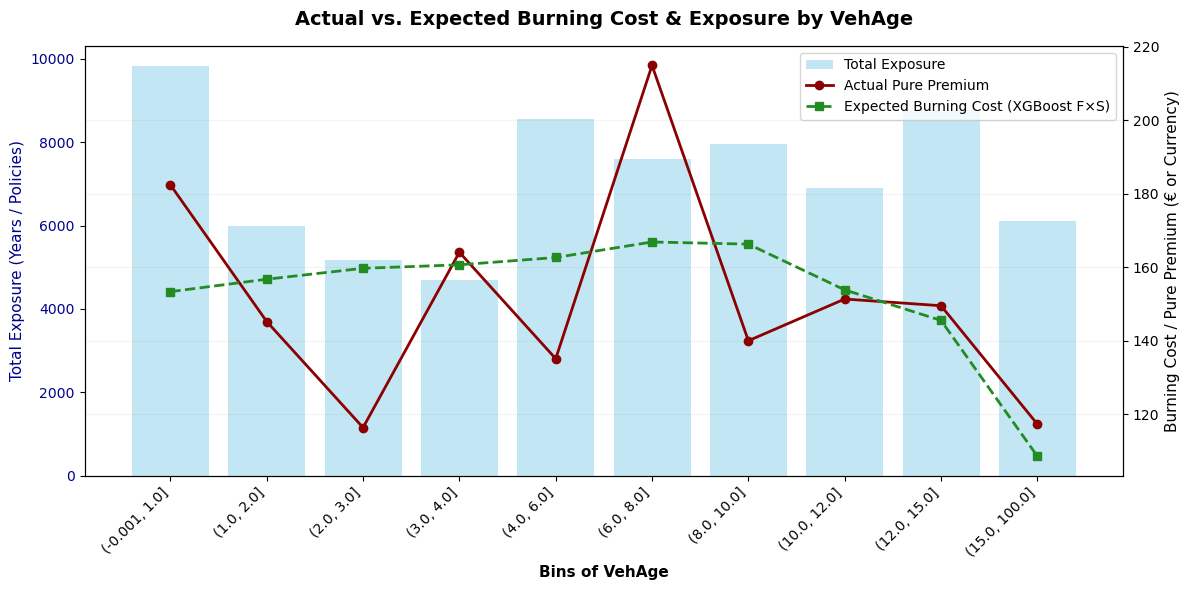

In [40]:
plot_burning_cost_vs_exposure(df_test,pred_freq,pred_sev*financial_ratio,feature_name="VehAge",num_bins=10)

C:\Users\Roshmi\AppData\Local\Temp\ipykernel_7600\3200124078.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = plot_df.groupby("Bin_Interval").agg(
C:\Users\Roshmi\AppData\Local\Temp\ipykernel_7600\3200124078.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(grouped["Bin"], rotation=45, ha="right")


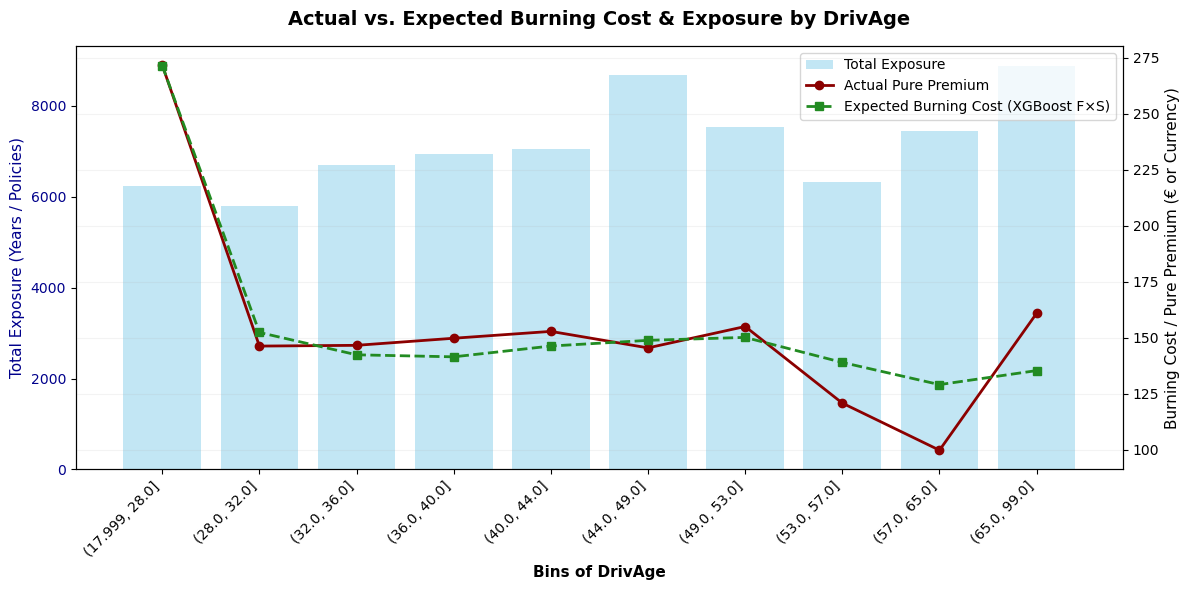

In [41]:
plot_burning_cost_vs_exposure(df_test,pred_freq,pred_sev*financial_ratio,feature_name="DrivAge",num_bins=10)

C:\Users\Roshmi\AppData\Local\Temp\ipykernel_7600\3200124078.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(grouped["Bin"], rotation=45, ha="right")


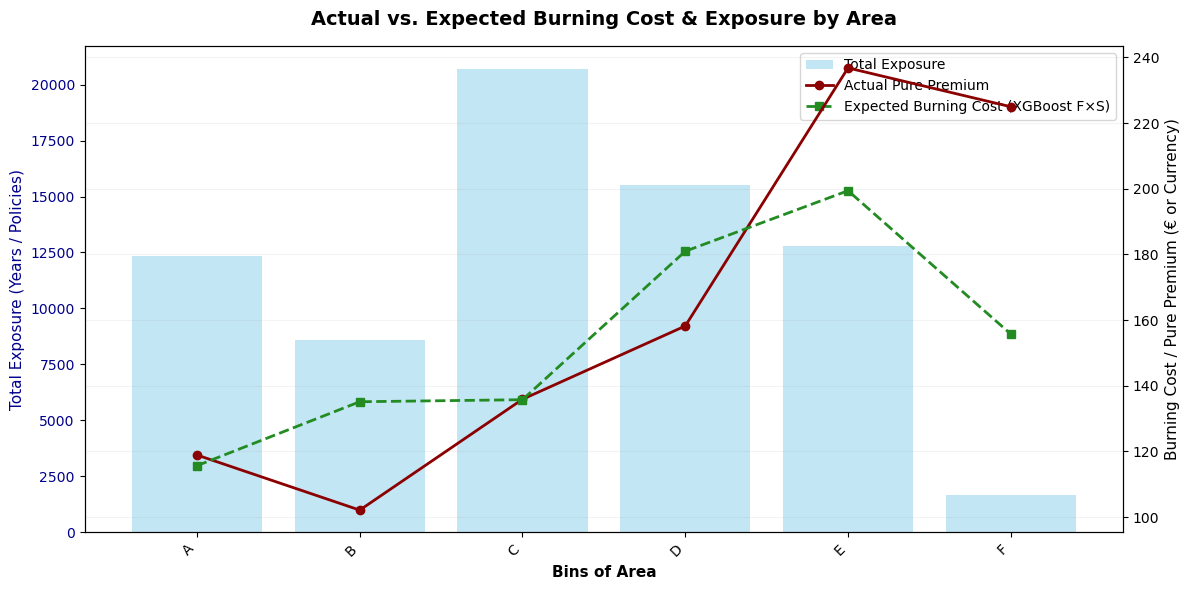

In [42]:
plot_burning_cost_vs_exposure(df_test,pred_freq,pred_sev*financial_ratio,feature_name="Area",num_bins=10)

In [43]:
# Calculate the raw error (Actual - Expected) per row
df_test["Error"] = df_test["ClaimAmount"] - (pred_freq * pred_sev * financial_ratio * df_test["Exposure"])

# Group by Area and look at the average dollar error
area_checks = df_test.groupby("Area")["Error"].mean()
print("Average Pricing Error per Policy Year by Area:")
print(area_checks)

Average Pricing Error per Policy Year by Area:
Area
A     1.936070
B   -18.771484
C     0.069897
D   -11.551686
E    17.426210
F    31.537809
Name: Error, dtype: float64


C:\Users\Roshmi\AppData\Local\Temp\ipykernel_7600\3200124078.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(grouped["Bin"], rotation=45, ha="right")


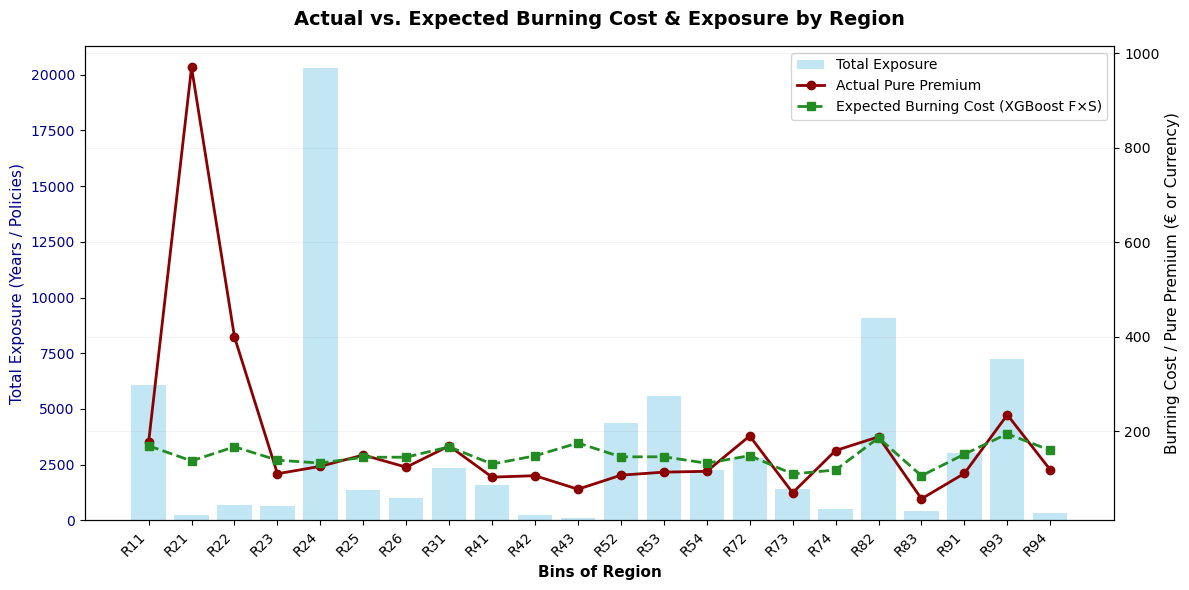

In [44]:
plot_burning_cost_vs_exposure(df_test,pred_freq,pred_sev*financial_ratio,feature_name="Region",num_bins=10)

C:\Users\Roshmi\AppData\Local\Temp\ipykernel_7600\3200124078.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(grouped["Bin"], rotation=45, ha="right")


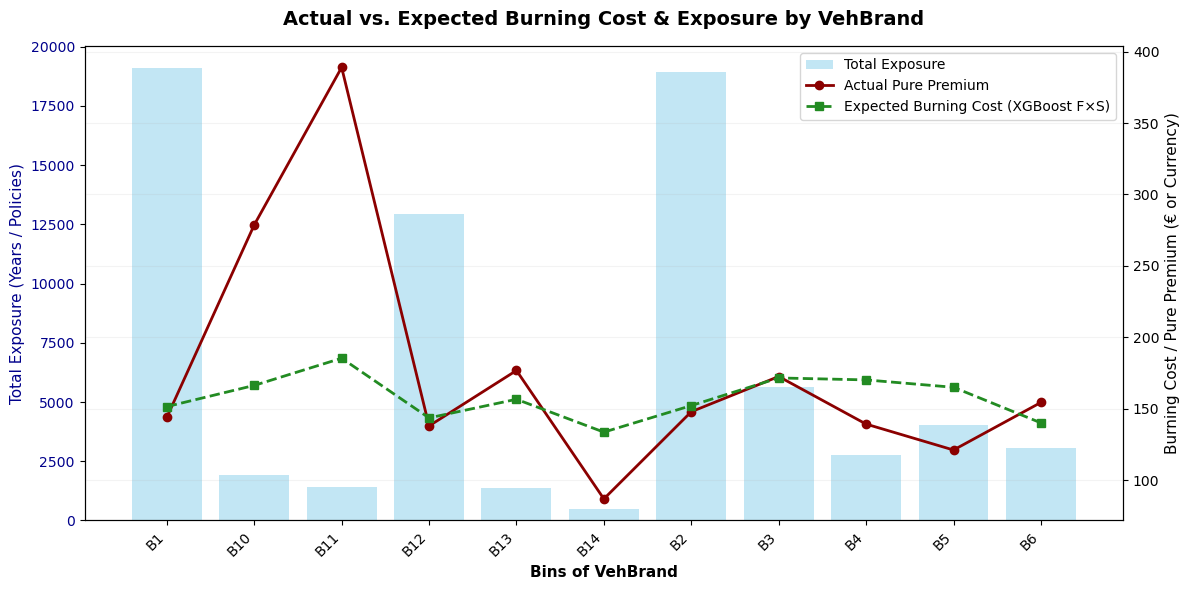

In [45]:
plot_burning_cost_vs_exposure(df_test,pred_freq,pred_sev*financial_ratio,feature_name="VehBrand",num_bins=10)

C:\Users\Roshmi\AppData\Local\Temp\ipykernel_7600\3200124078.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = plot_df.groupby("Bin_Interval").agg(
C:\Users\Roshmi\AppData\Local\Temp\ipykernel_7600\3200124078.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(grouped["Bin"], rotation=45, ha="right")


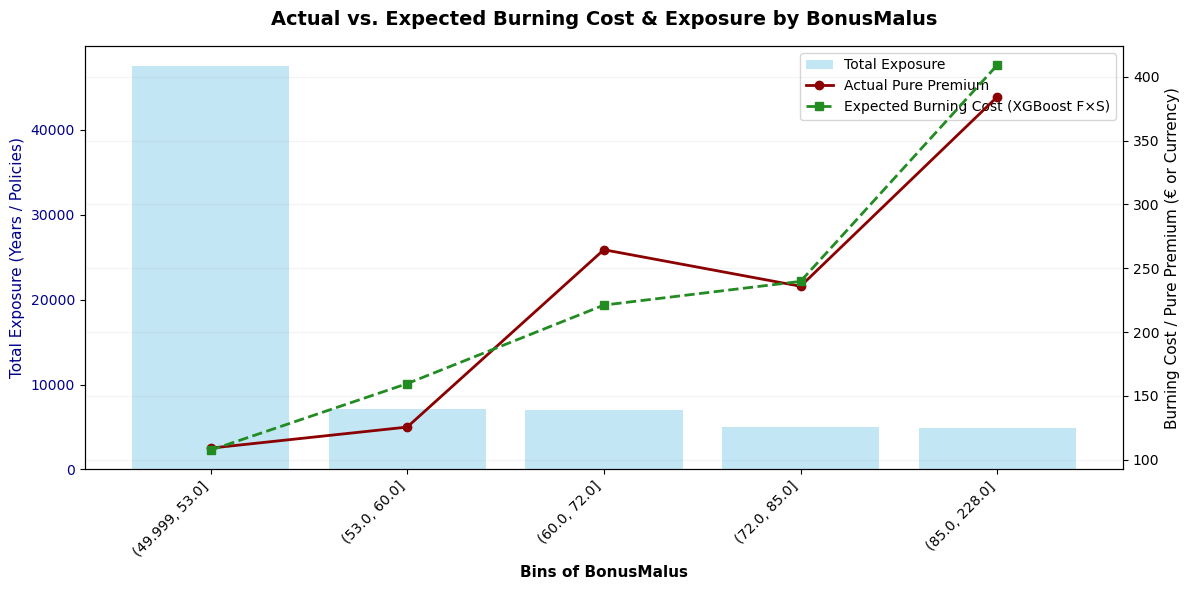

In [46]:
plot_burning_cost_vs_exposure(df_test,pred_freq,pred_sev*financial_ratio,feature_name="BonusMalus",num_bins=10)

In [48]:
import itertools
# --- 1. Define Representative Tiers for Your Agents ---
tier_driver_age = [18, 25, 35, 45, 55, 65, 75]
tier_vehicle_age = [0, 2, 5, 8, 12, 20]
tier_bonus_malus = [50, 60, 70, 85, 100, 150]

# Extract unique text categories directly from your data
tier_area = df["Area"].unique()
tier_region = df["Region"].unique()
tier_brand = df["VehBrand"].unique()

# --- 2. Generate Streamlined Combinations (No Density_log or VehGas) ---
all_combinations = list(
    itertools.product(
        tier_area,
        tier_region,
        tier_brand,
        tier_vehicle_age,
        tier_driver_age,
        tier_bonus_malus,
    )
)

# Convert to a lookup DataFrame
rate_chart = pd.DataFrame(
    all_combinations,
    columns=[
        "Area",
        "Region",
        "VehBrand",
        "VehAge",
        "DrivAge",
        "BonusMalus",
    ],
)

# --- 3. Process the Grid to Match Model Features ---
# Set standard baseline values for the features hidden from the agents
rate_chart["VehGas"] = df["VehGas"].mode()[0]  # Uses the most common fuel type (e.g., 'Regular')
rate_chart["Density_log"] = df["Density_log"].median()  # Uses the portfolio average density
rate_chart["VehPower"] = 5  # Baseline vehicle power placeholder

# Convert text to 0/1 dummies exactly like your training dataset structure
cat_cols = ["Area", "VehBrand", "VehGas", "Region"]
num_cols = ["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density_log"]

grid_numeric = pd.get_dummies(rate_chart[cat_cols], drop_first=True)
grid_features = pd.concat([rate_chart[num_cols], grid_numeric], axis=1)

# Alignment: Ensure the grid has the exact same dummy columns as your training matrix
for col in X_train.columns:
    if col not in grid_features.columns:
        grid_features[col] = 0

# Reorder columns to match training matrix configuration exactly
grid_features = grid_features[X_train.columns]

# --- 4. Calculate the Calibrated Risk Premium ---
grid_pred_freq = model_freq.predict(grid_features)
grid_pred_sev = model_sev.predict(grid_features)

# Apply your established financial_ratio multiplier
rate_chart["Risk_Premium"] = (
    grid_pred_freq * grid_pred_sev * financial_ratio
).round(2)

# --- 5. Export Clean Look-up Files for Distribution ---
# Drop the background processing features before finalizing the rate card
rate_chart_clean = rate_chart.drop(columns=["Density_log", "VehGas", "VehPower"])

# Export the clean file with filters ready for Excel
rate_chart_clean.to_excel("C:/Users/Roshmi/OneDrive/Desktop/Risk_Premium_Rate_Card.xlsx", index=False)
